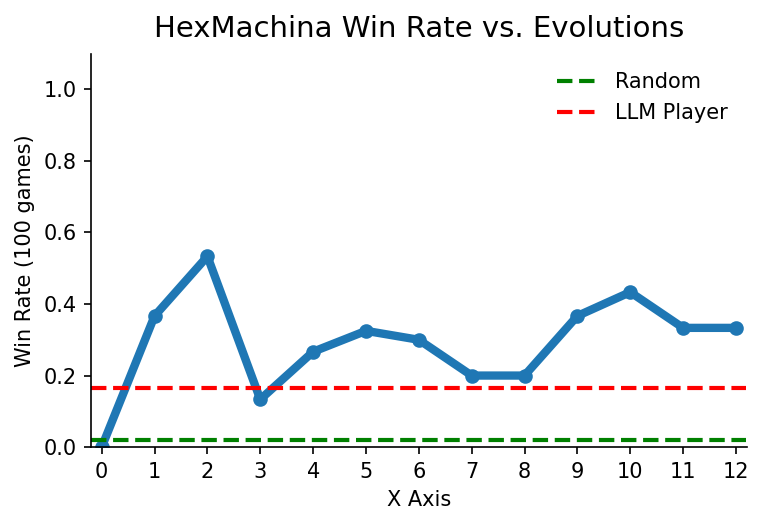

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

def plot_step_series(
    text_block: str,
    title: str = "Title",
    x_label: str = "X Axis",
    y_label: str = "Y Axis",
    baselines=None,              
    ylim: tuple | None = (0, 1), # set None to auto
    savepath: str | None = None  # e.g., "figure.png" (also saves a PDF with same stem)
):
    """
    Parse a 'Step / WinRate(100)' table and plot a research-paper style line plot.
    - baselines can be:
        • a list of numbers [0.8, 1.0]
        • or a list of tuples: [(y, label, color), ...]
    """
    # ---- parse the pasted table ----
    steps, vals = [], []
    lines = [ln.strip() for ln in text_block.strip().splitlines() if ln.strip()]
    # skip header row (expects something like: "Step    WinRate(100)")
    for ln in lines[1:]:
        # split on tab or spaces
        parts = re.split(r"\s+", ln)
        if len(parts) < 2:
            continue
        steps.append(int(parts[0]))
        vals.append(float(parts[1]))

    x = np.array(steps, dtype=float)
    y = np.array(vals, dtype=float)

    # ---- draw ----
    plt.figure(figsize=(5.2, 3.6), dpi=150)
    ax = plt.gca()

    # main series (no error bars)
    ax.plot(x, y, "-o", linewidth=4, markersize=6, color="#1f77b4")

    # baselines
    legend_items = []
    if baselines:
        for i, b in enumerate(baselines):
            if isinstance(b, tuple):
                yb, label, color = (b + (None,))[:3]  # tolerate 2- or 3-tuples
                color = color or ("red" if i == 0 else "green")
            else:
                yb, label, color = float(b), None, ("red" if i == 0 else "green")
            ax.axhline(yb, linestyle="--", linewidth=2, color=color)
            if label:
                legend_items.append((yb, label, color))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(x.astype(int))
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xlim(x.min() - 0.2, x.max() + 0.2)
    ax.set_title(title, fontsize=14, pad=8)
    ax.spines[["top", "right"]].set_visible(False)

    # optional legend if you named baselines
    if legend_items:
        # create dummy handles just for labels
        handles = [plt.Line2D([0], [0], linestyle="--", color=c, linewidth=2, label=lbl)
                   for _, lbl, c in legend_items]
        ax.legend(handles=handles, frameon=False, loc="best")

    plt.tight_layout()

    if savepath:
        import os
        stem, _ = os.path.splitext(savepath)
        plt.savefig(f"{stem}.png", bbox_inches="tight")
        plt.savefig(f"{stem}.pdf", bbox_inches="tight")

    plt.show()


# -------- Example usage (paste your data here) --------
data = """
Evolution	WinRate(30)
0	0
1	0.3666666667
2	0.5333333333
3	0.1333333333
4	0.2666666667
5	0.325
6	0.3
7	0.2
8	0.2
9	0.3666666667
10	0.4333333333
11	0.3333333333
12	0.3333333333
"""

# You can pass just numbers for baselines, or (value, label, color)
plot_step_series(
    data,
    title="HexMachina Win Rate vs. Evolutions",
    y_label="Win Rate (100 games)",
    baselines=[(0.02, "Random", "green"), (0.164, "LLM Player", "red")],
    ylim=(0, 1.1),
    savepath=None  # e.g., "winrate_curve.png"
    highest_score=True
)
